# Phase 3 - Feature engineering
All features are computable **before the vehicle leaves**: plan, outlet, vehicle, calendar, traffic, road conditions, and history of earlier deliveries. The pipeline lives in `tools/task1/task1_features.py` so the final notebook reuses it unchanged.

| Family | Examples | Why |
|---|---|---|
| Order | log weight/volume/units, density, kg per unit, deferred | Service time scales with size (corr ~0.55) |
| Outlet | dock type, parking, mall, window open/close/width | Outlet explains ~53% of service-time variance |
| Vehicle | capacity, load factor, fuel | Each vehicle has one driver; vehicle explains ~13% |
| Leg + route | planned slack, seq, stops remaining, cumulative planned travel, weight still on board | Delay accumulates along the route |
| Context | payday distance, festival ramp, monsoon, traffic speed index at the planned hour, road disruption | Travel delay is ~ traffic x disruption (log corr 0.97) |
| History | smoothed past-only outlet/vehicle/district service ratio, late rate, travel residual, departure delay | Stable outlet/driver behaviour |
| **Route simulation** | expected arrival and slack after rolling each route forward | Turns the plan into a realistic ETA |


In [1]:
import sys, json; sys.path.append("../../tools/task1")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from task1_common import *
import task1_features as tf
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
t = load_task1_tables()

## 1. Inputs from Phase 2

In [2]:
train_lab = pd.read_pickle(INTERIM / 'train_labeled.pkl')
actuals = pd.read_pickle(INTERIM / 'train_actuals_diagnostic.pkl')
test_base = pd.read_pickle(INTERIM / 'test_features_base.pkl')
print(train_lab.shape, actuals.shape, test_base.shape)

(91894, 43) (91894, 13) (5014, 41)


## 2. Two facts behind the simulation
1. The dispatcher's plan uses **exactly** the service allowance as dwell time at each stop and ignores traffic.
2. Actual travel is very close to `planned travel x (100/speed_index) x (100/disruption_index)`.

So the plan is systematically optimistic in a *predictable* way, and we can re-run it realistically.

In [3]:
chk = train_lab.merge(actuals, on='delivery_id').merge(t['outlets'][['outlet_id', 'dock_type']], on='outlet_id') \
               .merge(t['service_allowance'], on=['brand', 'dock_type']).sort_values(['route_id', 'seq'])
dwell = chk.groupby('route_id').planned_depart_time_m.shift(-1) - chk.planned_arrival_time_m
print('planned dwell - allowance:', (dwell - chk.service_allowance_min).describe().round(2)[['count', 'mean', 'std', 'min', 'max']].to_dict())

lookup = tf._speed_lookup(t['traffic'])
roads = t['roads'].assign(date=lambda d: pd.to_datetime(d.date))
chk = chk.merge(roads, on=['district', 'date'], how='left')
spd = lookup(chk.district.values, chk.actual_depart_time_m.values, chk.monsoon.values)
expected = chk.planned_travel_duration_min * (100 / spd) * (100 / chk.disruption_index)
print('log corr(actual travel, expected travel at actual depart hour):', np.corrcoef(np.log(chk.actual_travel_duration_min), np.log(expected))[0, 1].round(3))
print('median actual / expected:', (chk.actual_travel_duration_min / expected).median().round(3))

planned dwell - allowance: {'count': 66696.0, 'mean': 0.0, 'std': 0.0, 'min': 0.0, 'max': 0.0}
log corr(actual travel, expected travel at actual depart hour): 0.98
median actual / expected: 1.0


## 3. Build the feature tables
History features: train rows only see history at least `HIST_GAP_DAYS` old (test is 2-42 days after the end of train), and smoothing priors are fixed (0 for log ratios, 0.2 late rate, 7.7 min departure delay), so no future or full-data statistic enters a train row.

In [4]:
print('HIST_GAP_DAYS =', tf.HIST_GAP_DAYS, '| M_SMOOTH =', tf.M_SMOOTH)
train_X, test_X, meta = tf.build_feature_tables(train_lab, actuals, test_base, t)
FEATURES, CATEGORICAL = meta['features'], meta['categorical']
print('train', train_X.shape, '| test', test_X.shape, '| features', len(FEATURES), '| categorical', len(CATEGORICAL))

HIST_GAP_DAYS = 21 | M_SMOOTH = 20
train (91894, 106) | test (5014, 104) | features 101 | categorical 12


## 4. Leakage and shift checks
1. No actual-time column or label in the feature list.
2. Every feature exists in both tables.
3. Adversarial validation: a classifier tries to tell recent train rows from test rows. **Folds are grouped by route** - all stops of a route share route-level values, so an ungrouped split leaks routes and inflates the AUC (we measured 0.92 ungrouped vs 0.66 grouped).

In [5]:
leaky = set(actuals.columns) - {'delivery_id'}
assert not (set(FEATURES) & leaky), set(FEATURES) & leaky
assert not (set(FEATURES) & set(meta['labels']))
assert set(FEATURES) <= set(test_X.columns)
print('no actual-time or label columns in features: OK')

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance

calendarish = {'month', 'days_since_payday', 'days_to_payday', 'is_payday', 'festival_ramp', 'is_holiday', 'monsoon', 'dow', 'is_weekend'}
history_derived = {f for f in FEATURES if 'hist' in f} | {'cum_exp_service_prev', 'plan_vs_hist_service_gap_prev'}
adv_feats = [f for f in FEATURES if f not in calendarish | history_derived]
recent = train_X[train_X.date >= '2025-02-01'].sample(15000, random_state=SEED)
adv = pd.concat([recent[adv_feats + ['route_id']].assign(y=0), test_X[adv_feats + ['route_id']].assign(y=1)], ignore_index=True)
tri, tei = next(GroupShuffleSplit(1, test_size=0.3, random_state=SEED).split(adv, adv.y, adv.route_id))
clf = HistGradientBoostingClassifier(max_iter=200, categorical_features='from_dtype', random_state=SEED).fit(adv[adv_feats].iloc[tri], adv.y.iloc[tri])
auc = roc_auc_score(adv.y.iloc[tei], clf.predict_proba(adv[adv_feats].iloc[tei])[:, 1])
print(f'adversarial AUC, route-grouped (plan/outlet/route/traffic features): {auc:.3f}  (0.5 = indistinguishable)')
pi = permutation_importance(clf, adv[adv_feats].iloc[tei], adv.y.iloc[tei], scoring='roc_auc', n_repeats=3, random_state=SEED)
print('what separates them:'); print(pd.Series(pi.importances_mean, adv_feats).sort_values(ascending=False).head(6).round(3))
print('\nmean disruption_index - recent train:', round(recent.disruption_index.mean(), 2), '| test:', round(test_X.disruption_index.mean(), 2))
print('Calendar and history features are excluded here: calendar trivially identifies the period, and history is frozen at the end of')
print('train for test rows (one value per outlet), which a classifier can fingerprint without that being a real distribution shift.')

no actual-time or label columns in features: OK
adversarial AUC, route-grouped (plan/outlet/route/traffic features): 0.659  (0.5 = indistinguishable)
what separates them:
disruption_index           0.128
district                   0.042
outlet_id                  0.020
speed_idx_arrive           0.019
cum_exp_travel_excess      0.014
sim_allow_delay_vs_plan    0.007
dtype: float64

mean disruption_index - recent train: 92.71 | test: 89.94
Calendar and history features are excluded here: calendar trivially identifies the period, and history is frozen at the end of
train for test rows (one value per outlet), which a classifier can fingerprint without that being a real distribution shift.


## 5. Missing values
HistGradientBoosting handles NaN natively; we just confirm missingness is structural, not a bug.

In [6]:
na = pd.DataFrame({'train': train_X[FEATURES].isna().mean(), 'test': test_X[FEATURES].isna().mean()})
print(na[(na > 0).any(axis=1)].round(4))
print('\nmin_slack_prev_stops is NaN exactly for first stops:', train_X.loc[train_X.min_slack_prev_stops.isna(), 'seq'].eq(0).all())
print('days_since_payday NaN only before the first payday in the calendar:', train_X.loc[train_X.days_since_payday.isna(), 'date'].max())

                       train    test
days_since_payday     0.0320  0.0000
min_slack_prev_stops  0.2742  0.2754

min_slack_prev_stops is NaN exactly for first stops: True
days_since_payday NaN only before the first payday in the calendar: 2024-01-24 00:00:00


## 6. Train vs test distribution of the strongest features
Test has more road disruption (monsoon-heavy window), so its simulated slack is lower - a real condition the simulation captures, not a bug.

In [7]:
key = ['plan_slack', 'sim_allow_slack', 'sim_hist_slack', 'exp_travel_ratio', 'disruption_index', 'log_weight', 'n_stops',
       'exp_service_hist', 'hist_outlet_late', 'hist_vehicle_log_travel_resid']
same_season = train_X[train_X.date.dt.month.isin([2, 3]) & (train_X.date.dt.year == 2025)]
print(pd.DataFrame({'train_all': train_X[key].mean(), 'train_FebMar25': same_season[key].mean(), 'test': test_X[key].mean()}).round(3))

                               train_all  train_FebMar25     test
plan_slack                       120.412          121.31  120.781
sim_allow_slack                   74.042           73.57   66.856
sim_hist_slack                    68.026          67.124   58.994
exp_travel_ratio                   1.577           1.597    1.707
disruption_index                  92.822          92.258   89.939
log_weight                         5.719           5.689    5.756
n_stops                            4.793           4.825    4.709
exp_service_hist                  16.984          16.865   17.502
hist_outlet_late                   0.196           0.193    0.197
hist_vehicle_log_travel_resid      0.052           0.056    0.057


## 7. Univariate signal
Quick ranking so we know what the models should find. Service: Spearman with `service_min`. Lateness: AUC of each numeric feature (direction-free).

c:\Users\Asanka\Desktop\Hackbots_Datathon\.venv\Lib\site-packages\pandas\core\nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


                         index  |spearman| service                    index  AUC late
0             exp_service_hist               0.658           sim_hist_slack     0.954
1    hist_outlet_log_svc_ratio               0.583          sim_allow_slack     0.948
2              order_volume_m3               0.523         sim_hist_arrival     0.904
3                   log_volume               0.523        sim_allow_arrival     0.897
4                   log_weight               0.511   sim_hist_delay_vs_plan     0.880
5              order_weight_kg               0.511    cum_exp_travel_excess     0.863
6                  order_units               0.378  sim_allow_delay_vs_plan     0.861
7                    log_units               0.378               plan_slack     0.859
8                 route_volume               0.341     min_slack_prev_stops     0.825
9   hist_vehicle_log_svc_ratio               0.295   planned_arrival_time_m     0.818
10                route_weight               0.284    

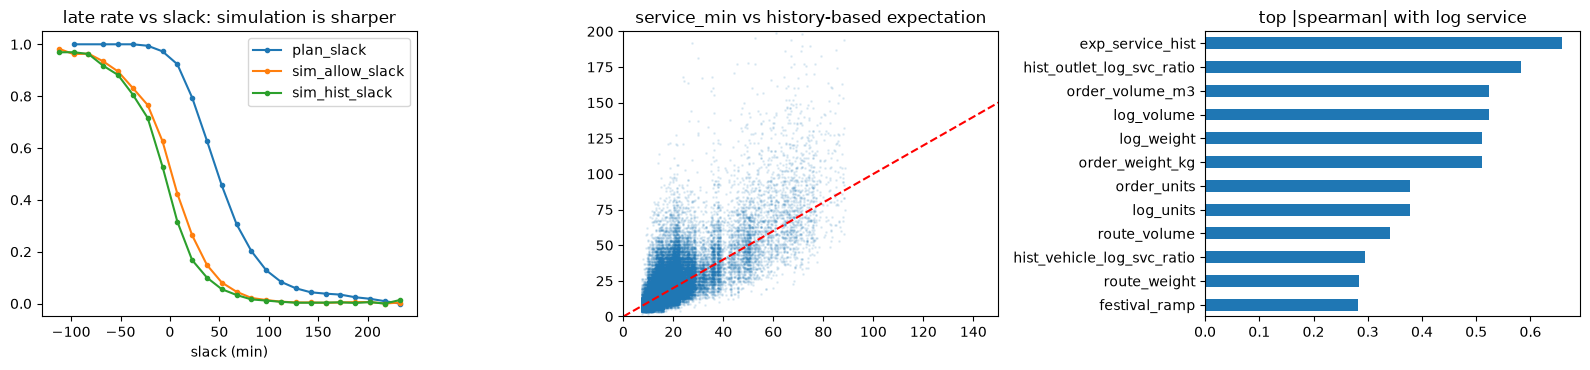

In [8]:
num = [f for f in FEATURES if f not in CATEGORICAL]
svc_rank = train_X[num].corrwith(np.log(train_X.service_min), method='spearman').abs().sort_values(ascending=False)
def auc_free(x, y):
    m = x.notna(); a = roc_auc_score(y[m], x[m]); return max(a, 1 - a)
late_rank = pd.Series({f: auc_free(train_X[f], train_X.late) for f in num}).sort_values(ascending=False)
print(pd.concat([svc_rank.head(15).rename('|spearman| service').reset_index(), late_rank.head(15).rename('AUC late').reset_index()], axis=1).round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for c in ['plan_slack', 'sim_allow_slack', 'sim_hist_slack']:
    b = pd.cut(train_X[c], np.arange(-120, 241, 15)); r = train_X.groupby(b, observed=True).late.mean()
    ax[0].plot([i.mid for i in r.index], r.values, marker='.', label=c)
ax[0].legend(); ax[0].set_title('late rate vs slack: simulation is sharper'); ax[0].set_xlabel('slack (min)')
ax[1].scatter(train_X.exp_service_hist, train_X.service_min, s=1, alpha=.1); ax[1].set_xlim(0, 150); ax[1].set_ylim(0, 200)
ax[1].set_title('service_min vs history-based expectation'); ax[1].plot([0, 150], [0, 150], 'r--')
svc_rank.head(12)[::-1].plot.barh(ax=ax[2]); ax[2].set_title('top |spearman| with log service')
plt.tight_layout(); plt.show()

## 8. Save model-ready tables

In [9]:
PROCESSED.mkdir(parents=True, exist_ok=True)
train_X.to_pickle(PROCESSED / 'task1_train_features.pkl')
test_X.to_pickle(PROCESSED / 'task1_test_features.pkl')
with open(PROCESSED / 'task1_feature_meta.json', 'w') as f:
    json.dump({**meta, 'hist_gap_days': tf.HIST_GAP_DAYS, 'm_smooth': tf.M_SMOOTH}, f, indent=1)
print('saved', train_X.shape, test_X.shape, '| features:', len(FEATURES))

saved (91894, 106) (5014, 104) | features: 101


### Feature decisions (feeds the preprocessing document)
| # | Decision | Reason |
|---|---|---|
| 1 | Only planning-time inputs; actual times only through *past* aggregates | Actual times do not exist at prediction time |
| 2 | Route simulation with traffic x disruption travel, outlet-specific service, window waiting, vehicle departure delay | The plan ignores traffic and real service; simulated slack is far more predictive than planned slack |
| 3 | History lagged by 21 days for train rows | Matches the 2-42 day horizon of the test set, so validation is not optimistic |
| 4 | Smoothed history with fixed priors | Stable for rarely-seen keys and no full-data leakage |
| 5 | Keep `outlet_id` / `vehicle_id` as categoricals | All test outlets/vehicles appear in train with many rows |
| 6 | NaNs left for the model | Structural only (first stop, pre-first-payday) |
| 7 | Drop `hist_*_n` counts and `iso_week` | Pure time proxies: counts only grow (test out of range); iso_week duplicates month |
| 8 | Adversarial validation grouped by route | Remaining shift (AUC ~0.66) is road disruption x district in the monsoon-heavy test window, which the features model explicitly |
